# SMOTE y ADASYN: técnicas de sobremuestreo sintético para datos desbalanceados

Este cuaderno explica en detalle **SMOTE** (*Synthetic Minority Over-sampling Technique*) y **ADASYN** (*Adaptive Synthetic Sampling*), dos técnicas ampliamente usadas para tratar el **desbalance de clases** en aprendizaje automático.


## 1. El problema: desbalance de clases

En muchos problemas de clasificación reales aparecen **conjuntos desbalanceados**: una clase (la **minoritaria**) tiene muchas menos observaciones que la otra (la **majoritaria**).

**Ejemplos:**
- Detección de fraude: 99,9 % transacciones legítimas, 0,1 % fraude
- Diagnóstico médico: enfermedades raras frente a pacientes sanos
- Detección de spam: pocos correos spam entre muchos legítimos

**¿Por qué es un problema?**
- Los clasificadores habituales optimizan la precisión global, que se puede lograr prediciendo siempre la clase mayoritaria
- El modelo puede no aprender los patrones de la clase minoritaria
- Métricas como la *accuracy* engañan (por ejemplo, 99,9 % de acierto prediciendo siempre «no fraude»)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")


### Crear un conjunto desbalanceado para la demostración


In [2]:
# Conjunto desbalanceado: 950 mayoritarios, 50 minoritarios (proporción 95:5)
X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0, n_informative=2,
                            n_clusters_per_class=1, weights=[0.95, 0.05], random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print("Distribución de clases en el conjunto de entrenamiento:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nClase minoritaria: {np.sum(y_train == 1)} muestras ({100*np.mean(y_train):.1f}%)")
print(f"Clase mayoritaria: {np.sum(y_train == 0)} muestras ({100*(1-np.mean(y_train)):.1f}%)")


Distribución de clases en el conjunto de entrenamiento:
0    661
1     39
Name: count, dtype: int64

Clase minoritaria: 39 muestras (5.6%)
Clase mayoritaria: 661 muestras (94.4%)


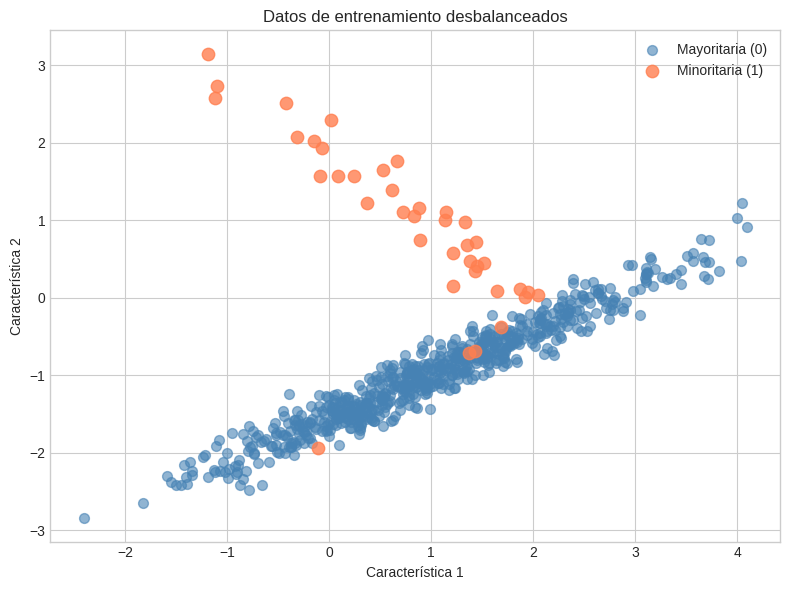

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', alpha=0.6, label='Mayoritaria (0)', s=50)
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', alpha=0.8, label='Minoritaria (1)', s=80)
ax.set_xlabel('Característica 1')
ax.set_ylabel('Característica 2')
ax.set_title('Datos de entrenamiento desbalanceados')
ax.legend()
plt.tight_layout()
plt.show()


---

## 2. SMOTE: *Synthetic Minority Over-sampling Technique*

**SMOTE** fue propuesto por Chawla et al. (2002) y es uno de los métodos de sobremuestreo más utilizados.

### Idea central
En lugar de **duplicar** muestras minoritarias (lo que favorece el sobreajuste), SMOTE crea muestras **sintéticas** interpolando entre instancias minoritarias existentes. Así se amplía la región de decisión de la clase minoritaria de forma más informativa.


### Algoritmo SMOTE (paso a paso)

Para cada muestra minoritaria $x_i$:

1. **Encontrar los k vecinos más cercanos** de $x_i$ entre otras muestras minoritarias (típicamente k=5).

2. **Elegir al azar un vecino** $x_{nn}$ entre esos k vecinos.

3. **Crear una muestra sintética** sobre el segmento entre $x_i$ y $x_{nn}$:

   $$x_{nuevo} = x_i + \lambda \cdot (x_{nn} - x_i)$$

   donde $\lambda$ es un número aleatorio en (0, 1). El nuevo punto queda entre los dos originales.

4. **Repetir** hasta alcanzar la proporción minoritaria:majoritaria deseada.


### Intuición visual

SMOTE coloca nuevas muestras sintéticas **entre** puntos minoritarios existentes:

- **Antes:** Pocas muestras minoritarias rodeadas por muchas mayoritarias.
- **Después de SMOTE:** Muestras sintéticas rellenan el espacio entre minoritarias.
- **Resultado:** Una frontera de decisión más densa y robusta para la clase minoritaria.


### Parámetros de SMOTE

| Parámetro | Descripción | Valor típico |
|-----------|-------------|--------------|
| `k_neighbors` | Número de vecinos más cercanos a considerar | 5 |
| `sampling_strategy` | Proporción objetivo (p. ej. `'auto'` para equilibrio, o un float) | `'auto'` o 0.5 |
| `random_state` | Reproducibilidad | 42 |

### Ventajas
- Reduce el sobreajuste frente al sobremuestreo aleatorio (no hay copias exactas).
- Genera muestras sintéticas diversas en el espacio de características.
- Simple y efectivo en muchos problemas.

### Limitaciones
- Trata por igual todas las minoritarias (puede sobremuestrear regiones ya densas).
- Puede crear sintéticas en zonas dominadas por la mayoritaria (ruido).
- Asume espacio continuo (para datos categóricos existe SMOTE-NC).


In [4]:
# Instalar imbalanced-learn si hace falta: pip install imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE


In [5]:
# Aplicar SMOTE
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Tras SMOTE - Distribución de clases en entrenamiento:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nTotal de muestras: {len(y_train_smote)} (antes: {len(y_train)})")


Tras SMOTE - Distribución de clases en entrenamiento:
0    661
1    661
Name: count, dtype: int64

Total de muestras: 1322 (antes: 700)


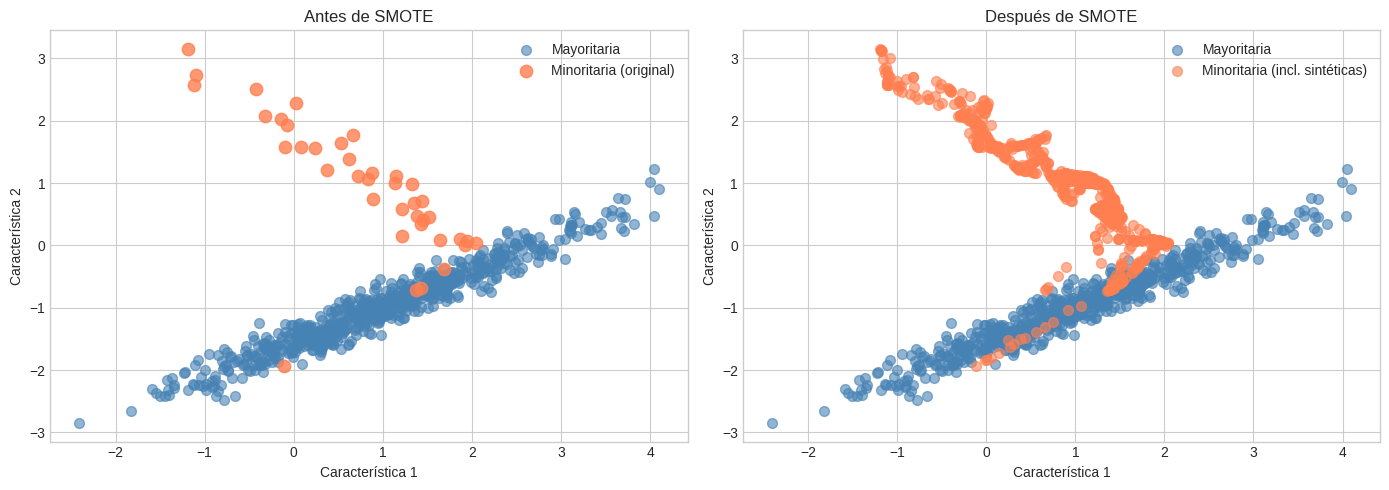

In [6]:
# Visualizar el resultado de SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', alpha=0.6, label='Mayoritaria', s=50)
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', alpha=0.8, label='Minoritaria (original)', s=80)
axes[0].set_title('Antes de SMOTE')
axes[0].set_xlabel('Característica 1')
axes[0].set_ylabel('Característica 2')
axes[0].legend()

axes[1].scatter(X_train_smote[y_train_smote==0, 0], X_train_smote[y_train_smote==0, 1], c='steelblue', alpha=0.6, label='Mayoritaria', s=50)
axes[1].scatter(X_train_smote[y_train_smote==1, 0], X_train_smote[y_train_smote==1, 1], c='coral', alpha=0.6, label='Minoritaria (incl. sintéticas)', s=50)
axes[1].set_title('Después de SMOTE')
axes[1].set_xlabel('Característica 1')
axes[1].set_ylabel('Característica 2')
axes[1].legend()

plt.tight_layout()
plt.show()


---

## 3. ADASYN: *Adaptive Synthetic Sampling*

**ADASYN** (He et al., 2008) es una extensión **adaptativa** de SMOTE. En lugar de tratar por igual todas las minoritarias, concentra la generación de sintéticas en instancias **difíciles de aprender**: rodeadas por mayoritarias o cerca de la frontera de decisión.


### En qué se diferencia ADASYN de SMOTE

| Aspecto | SMOTE | ADASYN |
|---------|-------|--------|
| **Estrategia** | Uniforme: mismo número de sintéticas por minoritaria | Adaptativa: más sintéticas para muestras «difíciles» |
| **Enfoque** | Todas las minoritarias por igual | Minoritarias en el borde o difíciles de clasificar |
| **Ponderación** | Sin pesos | Cada minoritaria recibe un peso ∝ desbalance local |
| **Resultado** | Distribución uniforme de sintéticas | Más densidad de sintéticas cerca de la frontera |

### Algoritmo ADASYN

1. **Calcular el grado de desbalance** de clases y cuántas muestras sintéticas generar.

2. **Para cada minoritaria** $x_i$, hallar sus k vecinos y calcular $r_i$ = proporción de mayoritarias entre esos vecinos (mayor $r_i$ = más difícil de clasificar).

3. **Normalizar** los $r_i$ a pesos $\hat{r}_i$ que suman 1.

4. **Para cada minoritaria**, generar $g_i$ sintéticas con $g_i \propto \hat{r}_i$.

5. **Cada sintética** se genera como en SMOTE: $x_{nuevo} = x_i + \lambda(x_{nn} - x_i)$.


### Cuándo usar ADASYN frente a SMOTE

- **SMOTE** cuando las minoritarias están relativamente bien repartidas y se busca un refuerzo uniforme y simple.
- **ADASYN** cuando la minoritaria tiene estructura compleja y hay muestras en «zonas de riesgo» (rodeadas por mayoritarias); ADASYN concentrará allí las sintéticas.


In [7]:
from imblearn.over_sampling import ADASYN

# Aplicar ADASYN
adasyn = ADASYN(n_neighbors=5, random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Tras ADASYN - Distribución de clases en entrenamiento:")
print(pd.Series(y_train_adasyn).value_counts().sort_index())
print(f"\nTotal de muestras: {len(y_train_adasyn)}")


Tras ADASYN - Distribución de clases en entrenamiento:
0    661
1    659
Name: count, dtype: int64

Total de muestras: 1320


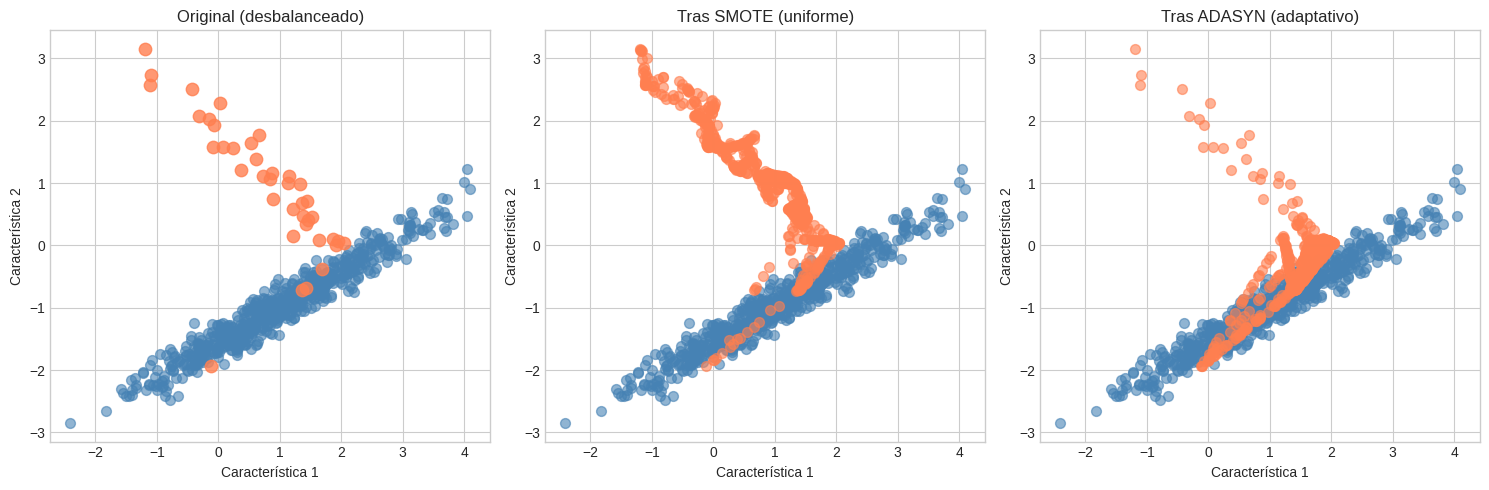

In [8]:
# Comparar: Original vs SMOTE vs ADASYN
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='steelblue', alpha=0.6, s=50)
axes[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='coral', alpha=0.8, s=80)
axes[0].set_title('Original (desbalanceado)')
axes[0].set_xlabel('Característica 1')
axes[0].set_ylabel('Característica 2')

axes[1].scatter(X_train_smote[y_train_smote==0, 0], X_train_smote[y_train_smote==0, 1], c='steelblue', alpha=0.6, s=50)
axes[1].scatter(X_train_smote[y_train_smote==1, 0], X_train_smote[y_train_smote==1, 1], c='coral', alpha=0.6, s=50)
axes[1].set_title('Tras SMOTE (uniforme)')
axes[1].set_xlabel('Característica 1')
axes[1].set_ylabel('Característica 2')

axes[2].scatter(X_train_adasyn[y_train_adasyn==0, 0], X_train_adasyn[y_train_adasyn==0, 1], c='steelblue', alpha=0.6, s=50)
axes[2].scatter(X_train_adasyn[y_train_adasyn==1, 0], X_train_adasyn[y_train_adasyn==1, 1], c='coral', alpha=0.6, s=50)
axes[2].set_title('Tras ADASYN (adaptativo)')
axes[2].set_xlabel('Característica 1')
axes[2].set_ylabel('Característica 2')

plt.tight_layout()
plt.show()


---

## 4. Comparación práctica: rendimiento del modelo


In [9]:
def entrenar_y_evaluar(X_tr, y_tr, nombre):
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_test)
    print(f"\n=== {nombre} ===")
    print(classification_report(y_test, y_pred, target_names=['Mayoritaria', 'Minoritaria']))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))
    return f1_score(y_test, y_pred, pos_label=1)

f1_original = entrenar_y_evaluar(X_train, y_train, 'Original (sin remuestreo)')
f1_smote = entrenar_y_evaluar(X_train_smote, y_train_smote, 'SMOTE')
f1_adasyn = entrenar_y_evaluar(X_train_adasyn, y_train_adasyn, 'ADASYN')



=== Original (sin remuestreo) ===
              precision    recall  f1-score   support

 Mayoritaria       0.97      1.00      0.99       284
 Minoritaria       1.00      0.50      0.67        16

    accuracy                           0.97       300
   macro avg       0.99      0.75      0.83       300
weighted avg       0.97      0.97      0.97       300

Matriz de confusión:
[[284   0]
 [  8   8]]

=== SMOTE ===
              precision    recall  f1-score   support

 Mayoritaria       0.99      1.00      0.99       284
 Minoritaria       0.92      0.75      0.83        16

    accuracy                           0.98       300
   macro avg       0.95      0.87      0.91       300
weighted avg       0.98      0.98      0.98       300

Matriz de confusión:
[[283   1]
 [  4  12]]

=== ADASYN ===
              precision    recall  f1-score   support

 Mayoritaria       0.98      0.81      0.89       284
 Minoritaria       0.18      0.75      0.29        16

    accuracy                

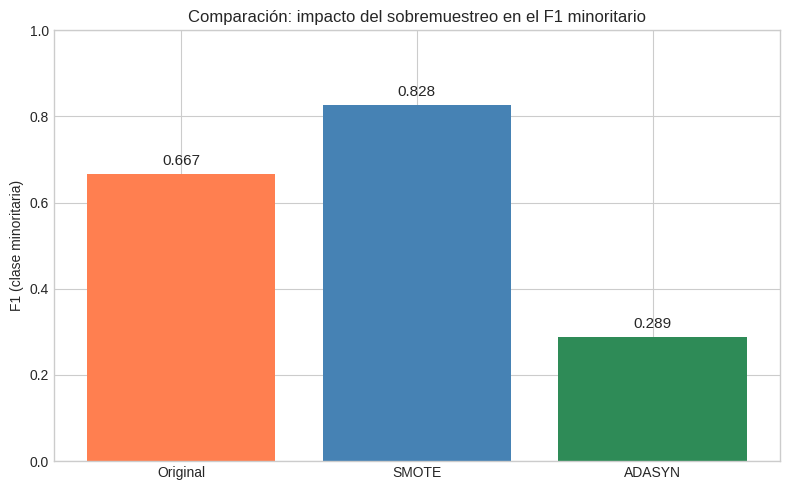

In [10]:
# Comparación de F1 en la clase minoritaria
fig, ax = plt.subplots(figsize=(8, 5))
metodos = ['Original', 'SMOTE', 'ADASYN']
f1_scores = [f1_original, f1_smote, f1_adasyn]
colors = ['coral', 'steelblue', 'seagreen']
bars = ax.bar(metodos, f1_scores, color=colors)
ax.set_ylabel('F1 (clase minoritaria)')
ax.set_title('Comparación: impacto del sobremuestreo en el F1 minoritario')
ax.set_ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{score:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()


---

## 5. Resumen y buenas prácticas

### Ideas clave

1. **SMOTE** crea minoritarias sintéticas por interpolación lineal entre vecinos. Es uniforme y sencillo.

2. **ADASYN** se adapta generando más sintéticas donde las minoritarias son más difíciles de clasificar (cerca de la frontera).

3. **Aplicar el remuestreo solo al conjunto de entrenamiento**, nunca al de prueba, para evitar fugas de información (*data leakage*).

4. **Usar pipelines** (por ejemplo `imblearn.pipeline.Pipeline`) para que el remuestreo ocurra correctamente dentro de cada pliegue de validación cruzada.

### Otras técnicas relacionadas

- **Borderline-SMOTE**: sobremuestreo solo de minoritarias cerca de la frontera
- **SMOTE-ENN**: SMOTE + *Edited Nearest Neighbors* (elimina ruido)
- **SMOTE-Tomek**: SMOTE + enlaces de Tomek (elimina mayoritarias conflictivas en el borde)
- **Submuestreo**: RandomUnderSampler, Tomek Links, NearMiss
- **Combinado**: SMOTE + submuestreo en desbalances extremos


In [11]:
# Ejemplo: pipeline (recomendado para validación cruzada correcta)
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('clasificador', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
print("Pipeline (SMOTE + regresión logística) - Informe de clasificación:")
print(classification_report(y_test, y_pred_pipe, target_names=['Mayoritaria', 'Minoritaria']))


Pipeline (SMOTE + regresión logística) - Informe de clasificación:
              precision    recall  f1-score   support

 Mayoritaria       0.99      1.00      0.99       284
 Minoritaria       0.92      0.75      0.83        16

    accuracy                           0.98       300
   macro avg       0.95      0.87      0.91       300
weighted avg       0.98      0.98      0.98       300



### Referencias

- Chawla, N. V., et al. (2002). «SMOTE: Synthetic Minority Over-sampling Technique.» *Journal of Artificial Intelligence Research*, 16, 321-357.
- He, H., et al. (2008). «ADASYN: Adaptive synthetic sampling approach for imbalanced learning.» *IEEE International Joint Conference on Neural Networks*.


Conclusión KEYLA VARGAS:
La gráfica muestra claramente el efecto de cada técnica sobre los datos desbalanceados.
En el Original se puede ver el problema que  hay muy pocos puntos naranjas (clase minoritaria) comparados con los azules (clase mayoritaria), lo que haría que el modelo ignore casi por completo a los naranjas.
Posteriormente, al aplicar SMOTE, los puntos naranjas se multiplican de forma uniforme a lo largo de toda su distribución original, llenando el espacio de manera pareja. El modelo ahora tiene suficientes ejemplos de la clase minoritaria para aprender, pero la distribución sintética es bastante regular y uniforme.
Ahora, si aplico ADASYN, también aumentan los puntos naranjas, pero la diferencia clave está en que se concentran más en la zona de frontera entre ambas clases (alrededor del centro del gráfico), que es precisamente donde el modelo tiene más dificultad para distinguir entre las dos clases. Esto hace que el modelo aprenda mejor los casos más difíciles.
En resumen, ambas técnicas resuelven el desbalance, pero ADASYN lo hace de forma más inteligente al enfocarse en los ejemplos más complicados, lo que en la práctica suele traducirse en un mejor rendimiento del clasificador en la clase minoritaria.